In [20]:
import confnotebook

In [21]:
from pathlib import Path

source = Path("../examples/test/full")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 10
[1] 126164
[2] 14964427_Енисейская ТГК-13-БРАЗ
[3] 14976087_АвеларСолар Тех-БРАЗ-1
[4] 15120979_Форвард Энерго-БРАЗ-1
[5] 15235008_ОГК-2-БРАЗ-1
[6] 25
[7] 33
[8] 4
[9] 44
[10] 7-1
[11] АС ВНИИМ Менделеева Д.И. - БРАЗ на 31.12.24
[12] АС ВНИИМ Менделеева Д.И. - РУ на 31.12.24
[13] АС КРЕЗОЛ-САЗ на 31.08.25
[14] АС Охрана Металлург-САЗ на 31.12.25
[15] АС РУ- ВОСЬМОЙ ВЕТРОПАРК
[16] АС Фрейт Линк-БРАЗ на 30.09.25
[17] АСР СДД 2 кв.2024 (подп. к-а)
[18] Акт сверки взаимных расчетов №00000379931 от 30.04.2024
[19] Акт сверки №0000
[20] Акт сверки №MOW00-0087974   от 10.06.2024
[21] Акт сверки №ТРБП-000006 от 10.01.2024
[22] Браз-Юнигрин Пауэр
[23] ЕВР-НКАЗ
[24] Неформализованный_первичный_документ_23_ИИА_03_00342_от_31_03
[25] Неформализованный_первичный_документ_23_ИИА_03_02596_от_31_03
[26] Неформализованный_первичный_документ_23_ИИА_03_03623_от_31_03
[27] Неформализованный_первичный_документ_23_ИИА_06_01794_от_30_06
[28] ПР_АС КРЕЗОЛ-САЗ на 31.08.25
[29] ПР_АС Фрейт Линк-

In [22]:
IDX_FILE = 4

In [23]:
from vision_core.loader.pdf_loader import PDFLoader

img = PDFLoader(pdf_bytes=files[IDX_FILE].read_bytes()).get_page_image(page_num=0, dpi=200)

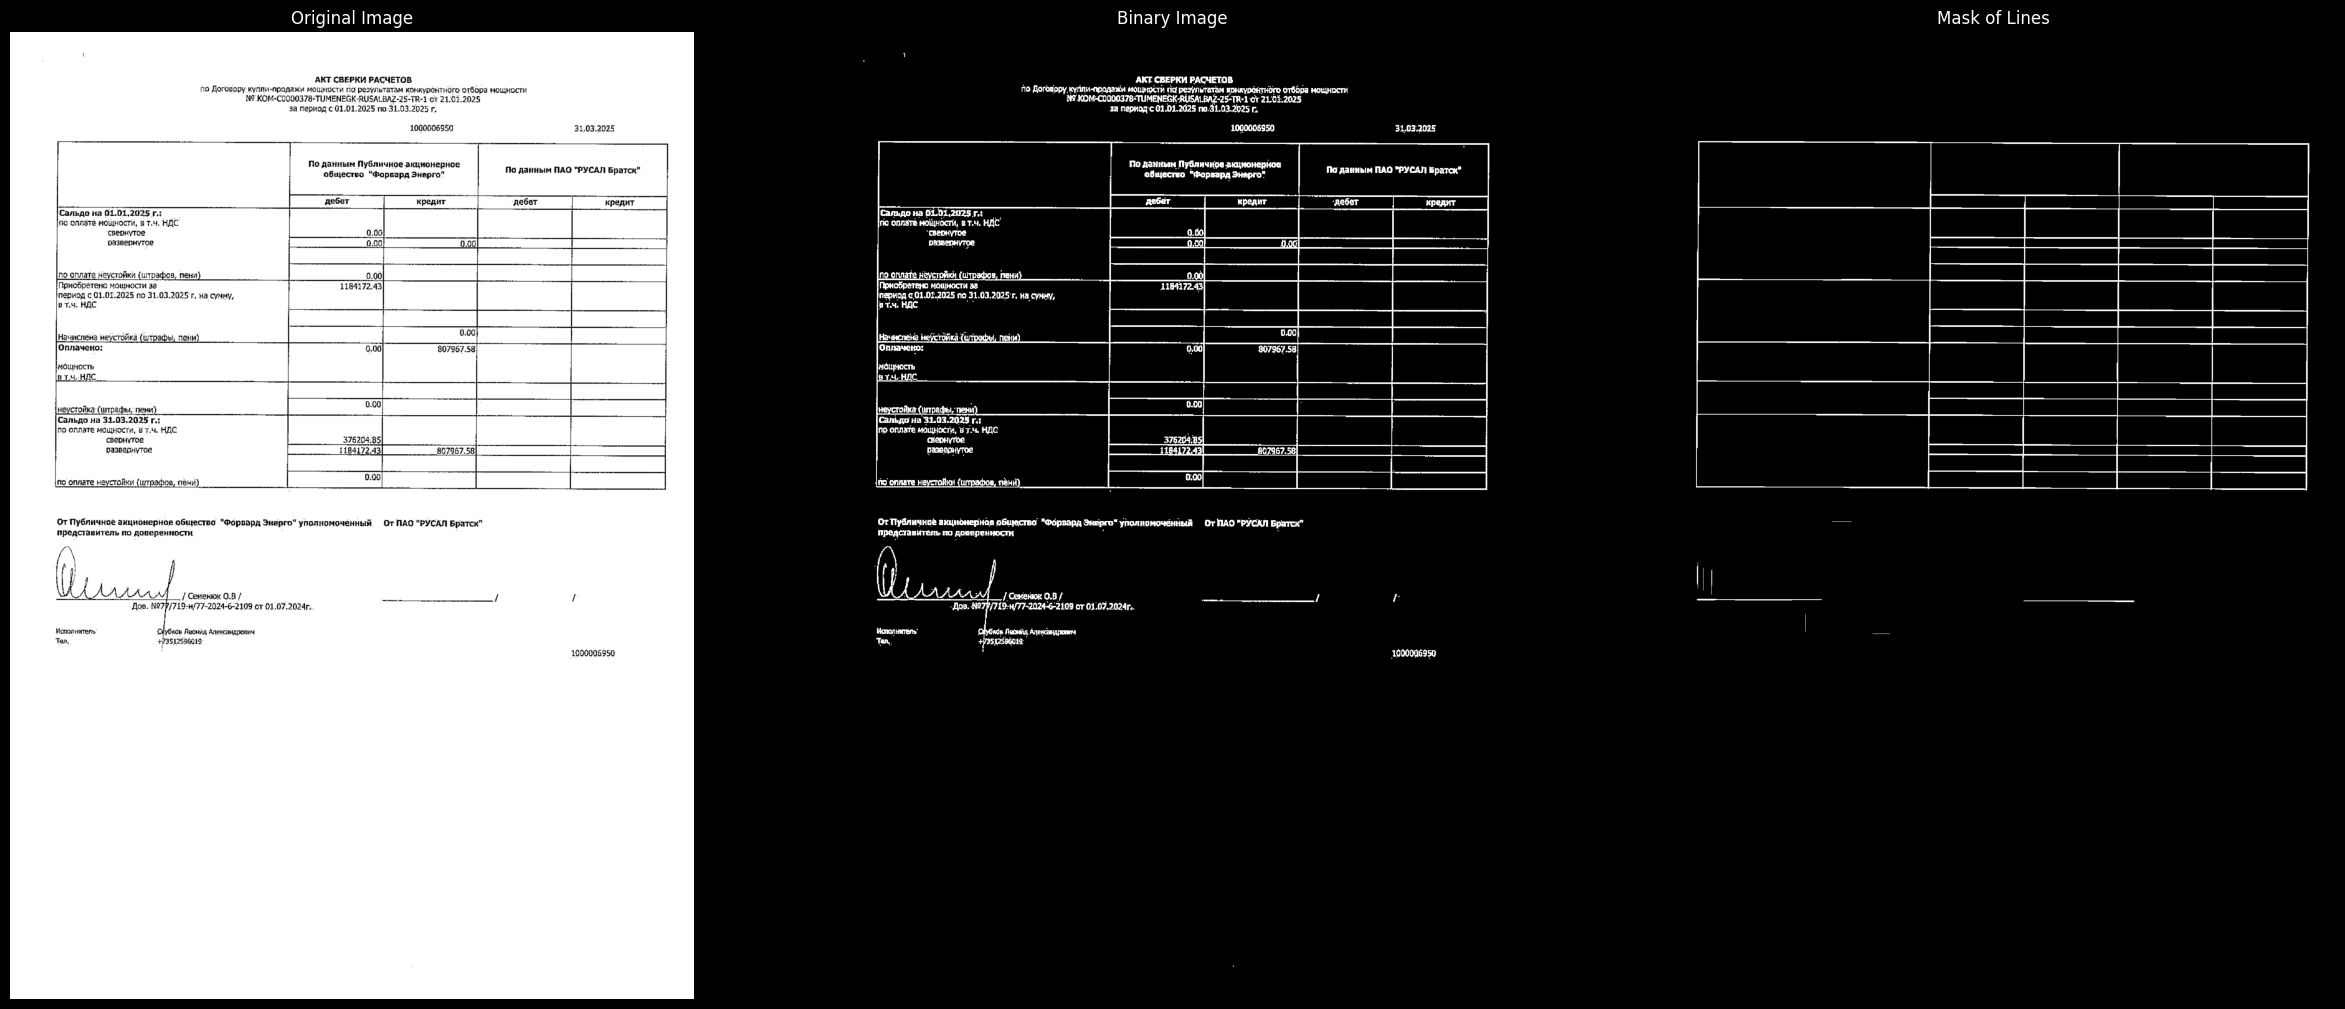

In [24]:
import cv2  # noqa: I001
import matplotlib.pyplot as plt
import numpy as np
from vision_core.utils import geometry_utils, image_utils
from vision_core.entities.bbox import BBox

gamma_img = image_utils.gamma_correction(img, gamma=10.0)
bin_img = image_utils.binary_threshold(gamma_img, block_size=15, C=5)


h_line_mask = image_utils.compute_horizontal_line_mask(bin_img, scale=40)
v_line_mask = image_utils.compute_vertical_line_mask(bin_img, median_height=40)
table_mask = image_utils.get_mask(h_line_mask, v_line_mask)

def extract_raw_tables(
    table_mask: np.ndarray,
    border_tol: int = 8,
    scale_width: float = 0.35,
    scale_height: float = 0.08,
    min_density: float = 0.01,
    intersection_over_min_thr: float = 0.2,
) -> list[BBox]:
    """Извлекает bounding boxes таблиц из маски таблицы.

    Args:
        table_mask: Бинарная маска, где белые пиксели соответствуют линиям таблицы.
        border_tol: Толерантность к границам изображения в пикселях. Таблицы, касающиеся границ, будут отфильтрованы.
        scale_width: Минимальная ширина таблицы относительно ширины изображения для фильтрации
        scale_height: Минимальная высота таблицы относительно ширины изображения для фильтрации
        min_density: Минимальная плотность белых пикселей внутри bounding box для таблиц, касающихся границ
        intersection_over_min_thr: Порог для объединения перекрывающихся bounding boxes (IoM > threshold)
    Returns:
        list[BBox]: Список bounding boxes таблиц, представленных в виде объектов BBox.
    """
    contours = geometry_utils.find_contours(table_mask)
    candidates: list[tuple[int, int, int, int]] = []
    H, W = table_mask.shape[:2]
    min_width = int(W * scale_width)
    min_height = int(H * scale_height)

    for contour in contours:
        x, y, w, h = geometry_utils.bounding_rect(contour)

        if w < min_width or h < min_height:
            continue

        if w > W * 0.95 and h > H * 0.95:
            continue

        touches_border = x <= border_tol or y <= border_tol or x + w >= W - border_tol or y + h >= H - border_tol
        density = geometry_utils.count_non_zero_pixels(geometry_utils.roi_from_xywh(table_mask, (x, y, w, h)))

        if touches_border and density < min_density:
            continue

        candidates.append((x, y, w, h))

    bboxes: list[BBox] = []
    for x, y, w, h in candidates:
        box = BBox(x_min=x, y_min=y, x_max=x + w, y_max=y + h)
        if any(
            kept.contains(box) or box.contains(kept) or kept.intersection_over_min(box) > intersection_over_min_thr
            for kept in bboxes
        ):
            continue
        bboxes.append(box)

    return bboxes

plt.figure(figsize=(30, 20))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(bin_img, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(table_mask, cmap="gray")
plt.title("Mask of Lines")
plt.axis("off")
plt.show()

[BBox(x_min=109.0, y_min=266.0, x_max=1592.0, y_max=1110.0)]


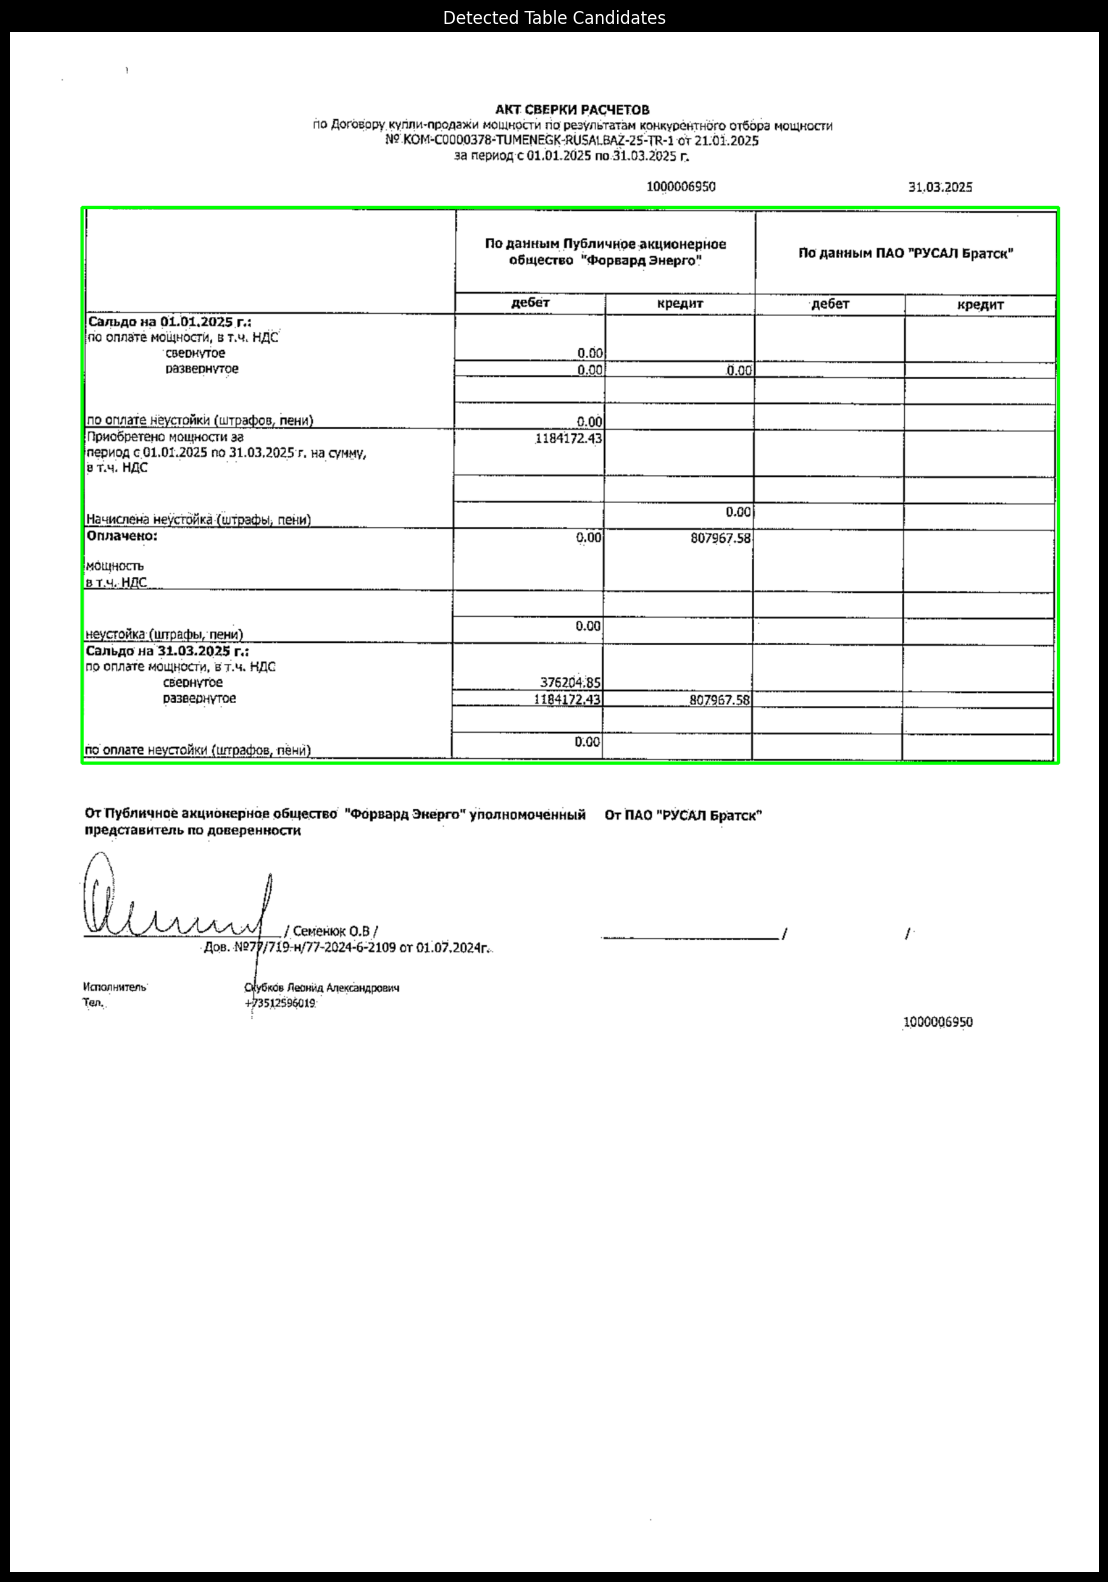

In [25]:
bboxes = extract_raw_tables(table_mask)
print(bboxes)
debug_img = img.copy()

for bbox in bboxes:
    x, y, w, h = bbox.to_tuple()
    cv2.rectangle(debug_img, (x, y), (w, h), (0, 255, 0), 3)

plt.figure(figsize=(30, 20))
plt.imshow(debug_img)
plt.title("Detected Table Candidates")
plt.axis("off")
plt.show()
 

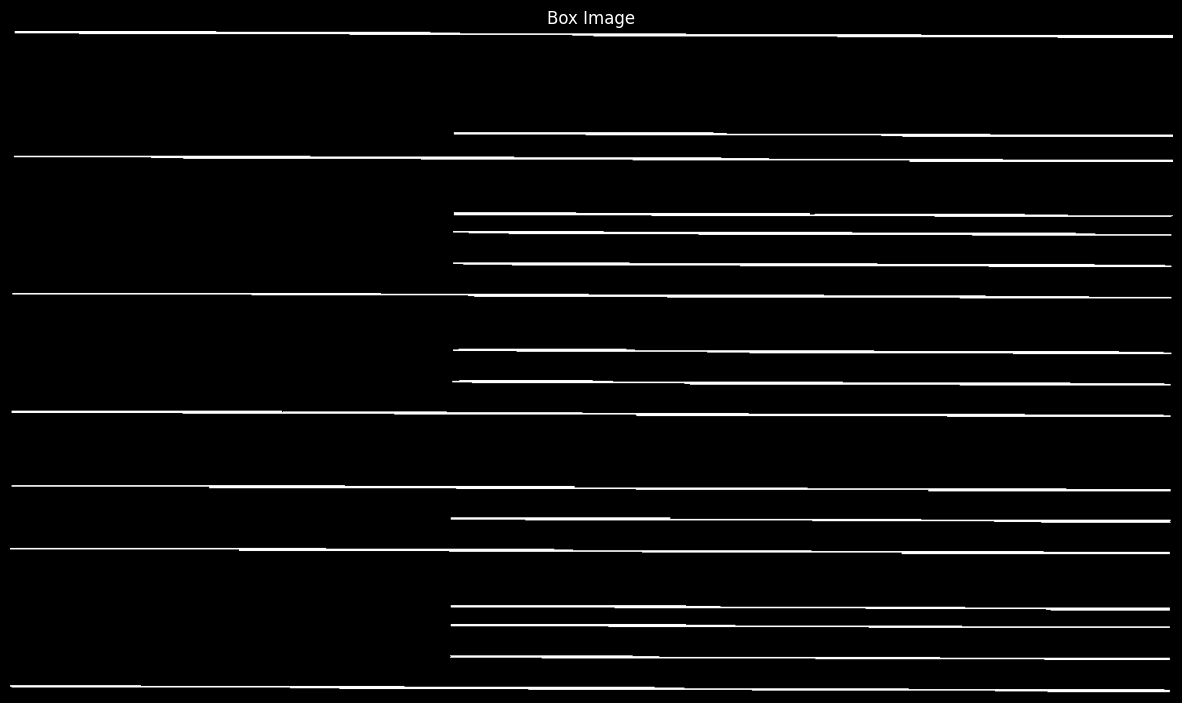

In [26]:
for bbox in bboxes:
    x, y, w, h = bbox.to_tuple()
    box_img = bbox.roi(bin_img)

    mask = image_utils.compute_horizontal_line_mask(box_img, scale=10)

    plt.figure(figsize=(15, 10))
    plt.imshow(mask, cmap="gray")
    plt.title("Box Image")
    plt.axis("off")

[0.24164926 0.2399684  0.24226063 0.2058651  0.21409497 0.19704145
 0.22265492 0.26444593 0.25750494 0.2337697  0.2442051  0.24814041
 0.25139034 0.25462452 0.20926955 0.24197415]
Estimated skew angle: 0.242 degrees
Used components: 16


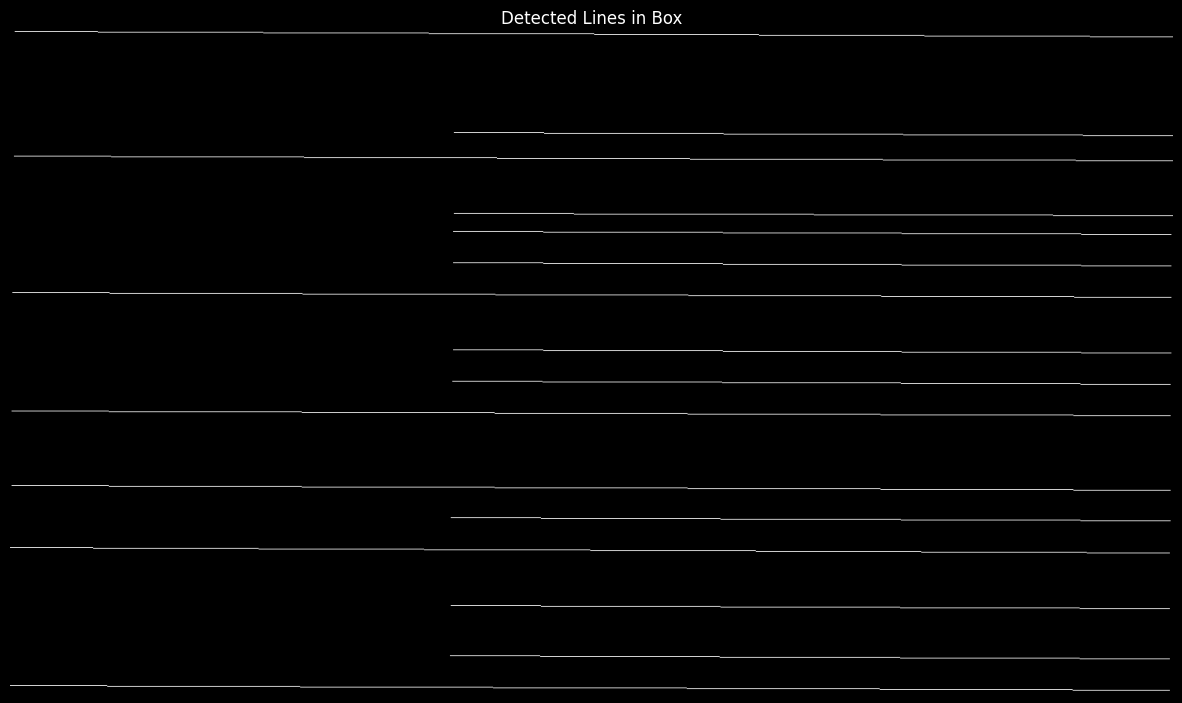

In [27]:
def _normalize_angle_deg(angle: float) -> float:
    if angle > 90:
        angle -= 180
    if angle < -90:
        angle += 180
    return angle


def _weighted_median(values: np.ndarray, weights: np.ndarray) -> float:
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    csum = np.cumsum(weights)
    idx = np.searchsorted(csum, 0.5 * csum[-1])
    return float(values[min(idx, len(values) - 1)])


all_angles: list[float] = []
all_weights: list[float] = []
debug_masks: list[np.ndarray] = []

for bbox in bboxes:
    box_bin = bbox.roi(bin_img)
    mask = image_utils.compute_horizontal_line_mask(box_bin, scale=10)

    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    d_mask = np.zeros_like(mask)

    for lbl in range(1, num):
        area = int(stats[lbl, cv2.CC_STAT_AREA])
        if area < 30:
            continue

        comp = (labels == lbl).astype(np.uint8) * 255
        cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if not cnts:
            continue

        cnt = max(cnts, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(cnt)
        if bw < 80 or bw < 6 * max(1, bh):
            continue

        vx, vy, x0, y0 = cv2.fitLine(cnt, cv2.DIST_L2, 0, 0.01, 0.01).reshape(-1)
        angle = _normalize_angle_deg(float(np.degrees(np.arctan2(vy, vx))))

        # Убираем явные выбросы: для deskew таблиц угол обычно малый
        if abs(angle) > 3.0:
            continue

        x_pts = cnt[:, 0, 0]
        x1, x2 = int(x_pts.min()), int(x_pts.max())
        if abs(vx) < 1e-6 or x2 <= x1:
            continue
        y1 = int(y0 + (x1 - x0) * (vy / vx))
        y2 = int(y0 + (x2 - x0) * (vy / vx))

        line_img = np.zeros_like(mask)
        cv2.line(line_img, (x1, y1), (x2, y2), 255, 1)
        line_pts = int(np.count_nonzero(line_img))
        if line_pts == 0:
            continue

        support = np.count_nonzero((line_img > 0) & (mask > 0)) / line_pts
        length = float(np.hypot(x2 - x1, y2 - y1))

        if support >= 0.9 and length >= 120:
            all_angles.append(angle)
            all_weights.append(length)
            cv2.line(d_mask, (x1, y1), (x2, y2), 128, 1)

    debug_masks.append(d_mask)

if not all_angles:
    angle = 0.0
    print("No reliable horizontal components found. Angle = 0.0")
else:
    a = np.array(all_angles, dtype=np.float32)
    w = np.array(all_weights, dtype=np.float32)
    print(a)
    angle = _weighted_median(a, w)
    print(f"Estimated skew angle: {angle:.3f} degrees")
    print(f"Used components: {len(all_angles)}")

# Показать отладочную маску для последнего bbox
if debug_masks:
    plt.figure(figsize=(15, 10))
    plt.imshow(debug_masks[-1], cmap="gray")
    plt.title("Detected Lines in Box")
    plt.axis("off")
    plt.show()

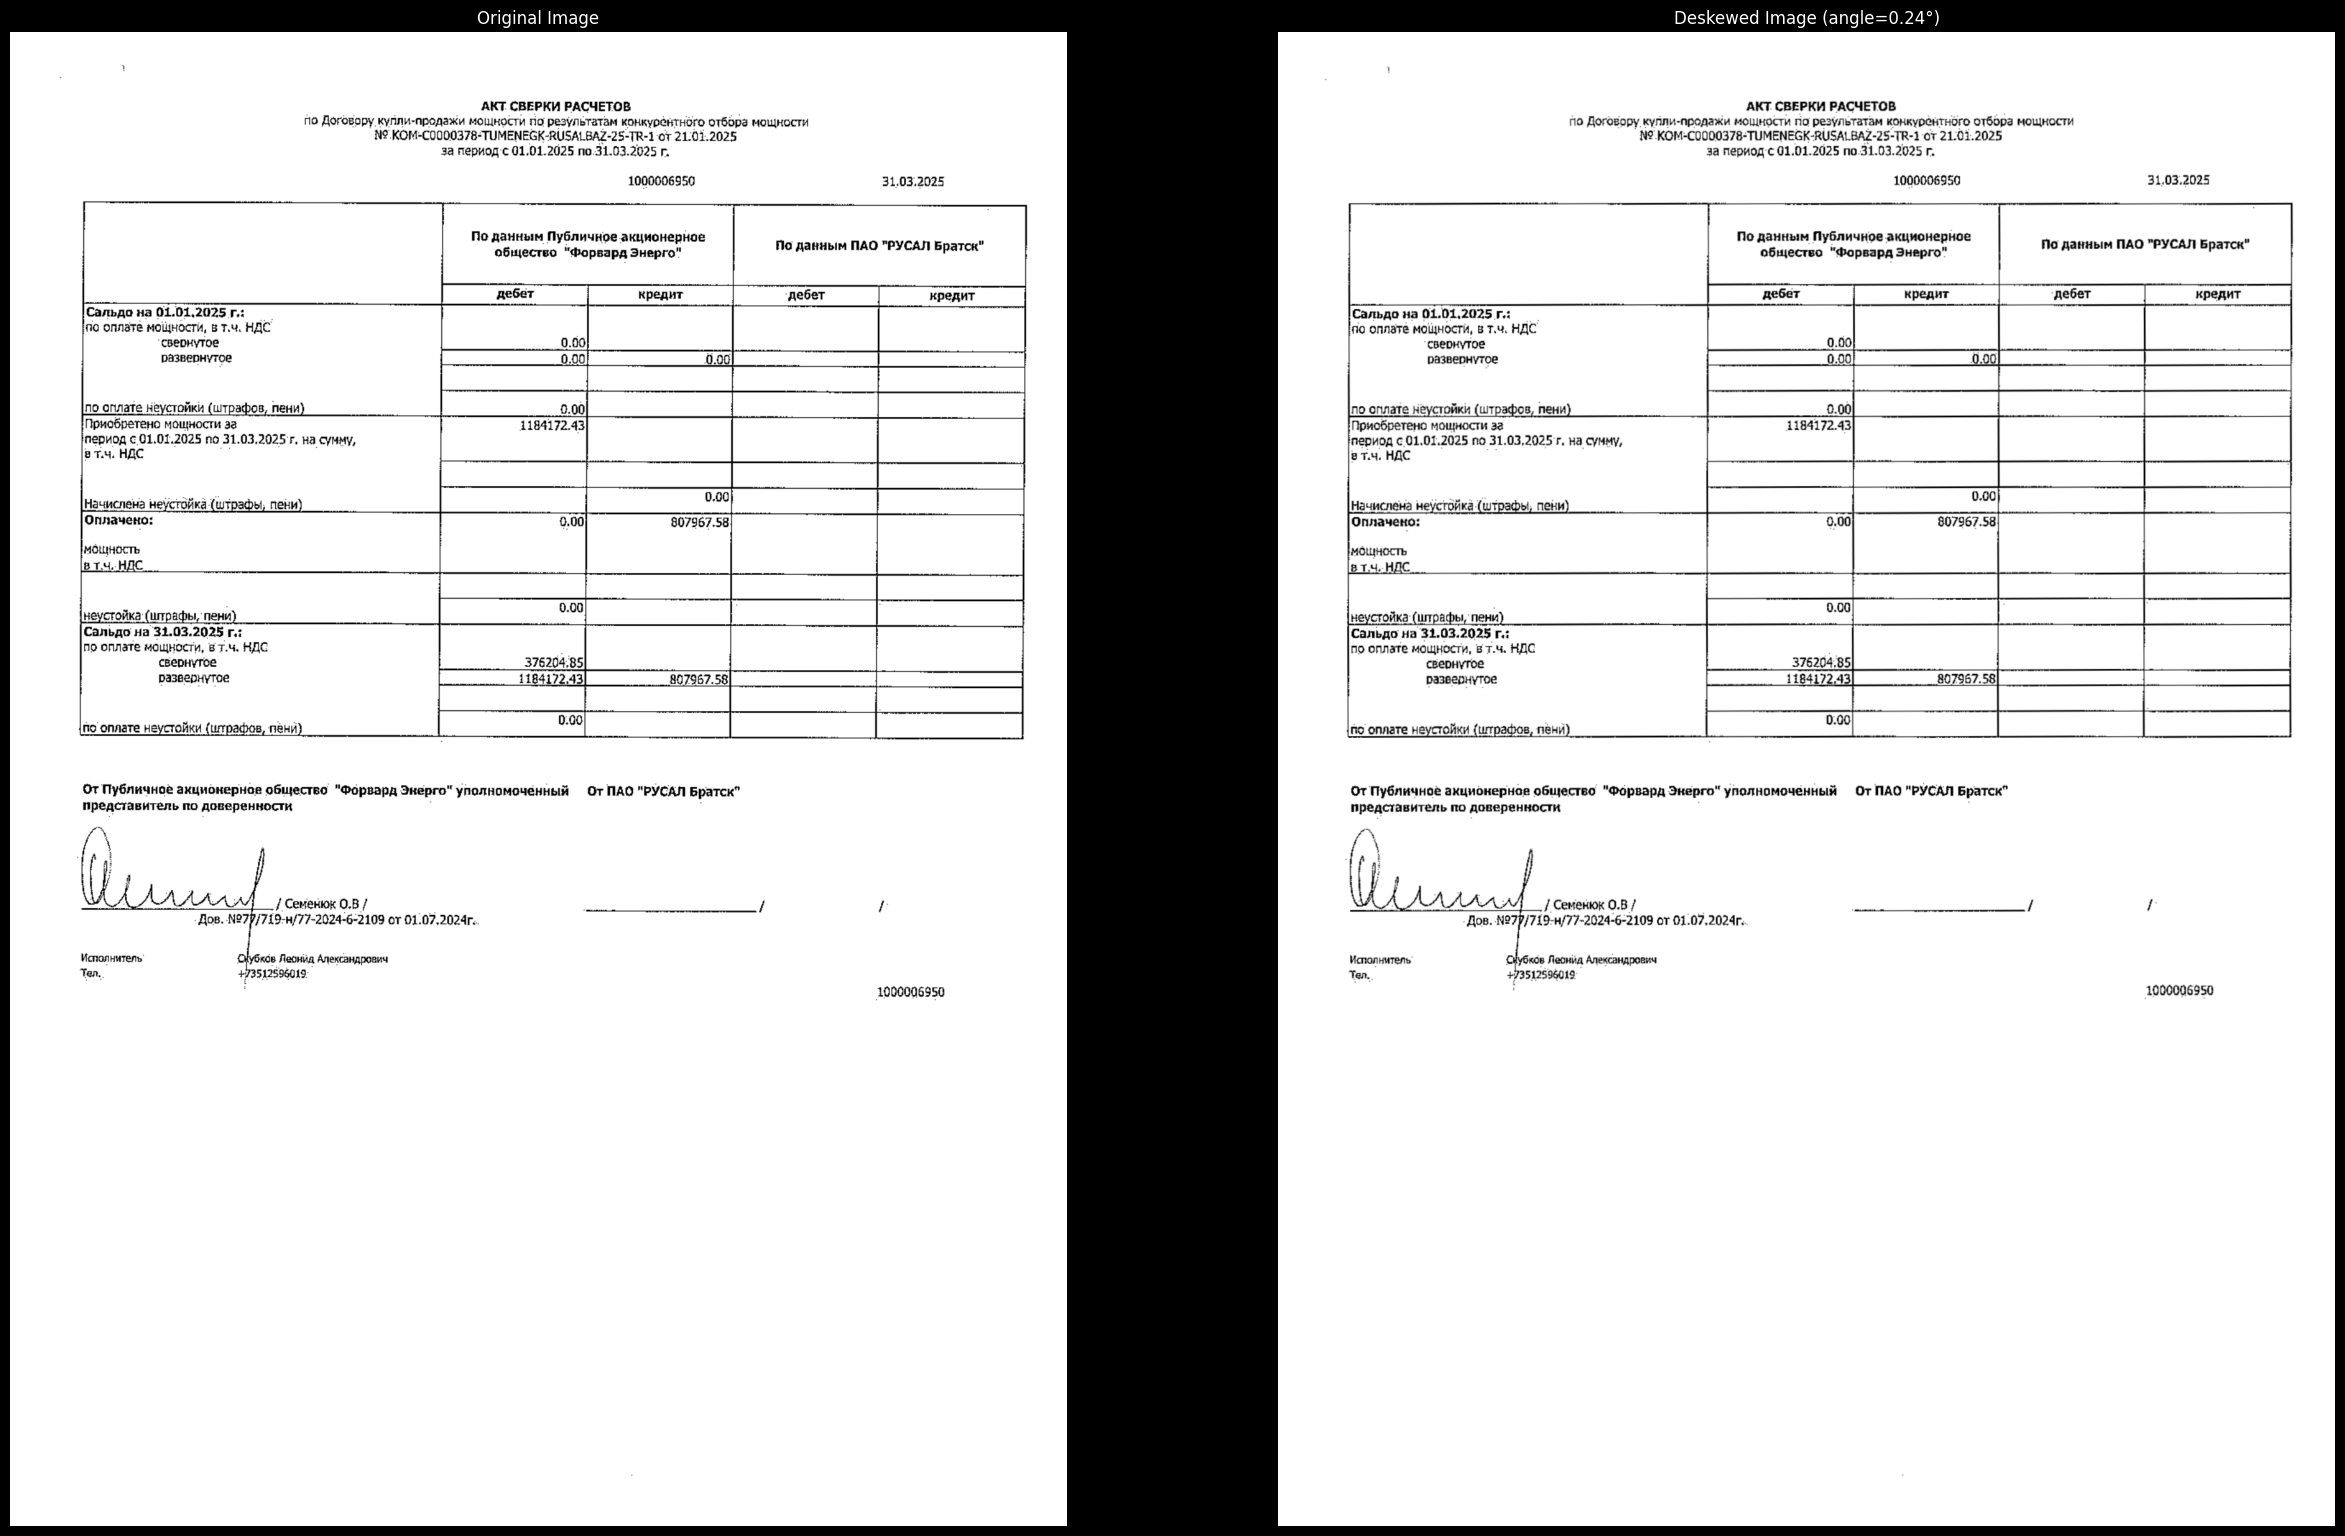

In [28]:
from vision_core.utils import image_utils

deskewed_img = image_utils.rotate_image(img, angle)

plt.figure(figsize=(30, 20))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(deskewed_img)
plt.title(f"Deskewed Image (angle={angle:.2f}°)")
plt.axis("off")
plt.show()
